# CelebA Interpolation

We have trained our neural network to disentangle the hair color representation from gender, and thus we will demonstrate this qualitatively through a visual experiment.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import re
from copy import copy
from pathlib import Path
from pprint import pprint

import lightning as pl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torchvision.datasets import CelebA
from torch.utils.data import DataLoader, random_split
import normflows as nf
from torchvision import transforms
from torchvision.utils import save_image, make_grid
import seaborn as sns
import matplotlib.pyplot as plt

from ciflows.datasets.causalceleba import CausalCelebA
from ciflows.datasets.multidistr import StratifiedSampler
from ciflows.datasets.causalceleba import CausalCelebAEmbedding
from ciflows.datasets.multidistr import StratifiedSampler, SynchronizedDataset
from ciflows.distributions.pgm import LinearGaussianDag
from ciflows.eval import load_model
from ciflows.reduction.resnetvae import DeepResNetVAE
from ciflows.datasets.causalceleba import CausalCelebAEyeGlasses
from ciflows.reduction import make_nf_model

import copy
import torch
from torchvision import transforms
from ciflows.diffusion.ddpm.wrapper import DDPMWrapper
from ciflows.diffusion.ddpm.ddpm_form2 import DDPMv2
from ciflows.diffusion.ddpm.ddpm import DDPM
from ciflows.diffusion.ddpm.unet_openai import SuperResModel
from ciflows.diffusion.ddpm.vae import VAE as BACKVAE

/Users/adam2392/miniforge3/envs/ciflows/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
print(torch.__version__)

2.4.1.post2


In [4]:

# Option 2: Display the grid using matplotlib
def tensor_to_numpy(image_tensor):
    # Convert from tensor to NumPy for plotting
    image = image_tensor.cpu().permute(1, 2, 0)  # (C, H, W) -> (H, W, C)
    return image.numpy()

## Setup - directories and GPU selection

In [4]:
root = Path("/Users/adam2392/pytorch_data/")
root = Path('/local/eb/adam2392/')
seed_offset = 1

# set seed
seed = 1234
np.random.seed(seed + seed_offset)
pl.seed_everything(seed + seed_offset, workers=True)

image_size = 128
latent_dim = 48
num_blocks_per_stage = 3
debug = False

if torch.cuda.is_available():
    device = torch.device("cuda")
    accelerator = "cuda"

    # Get the index of the current device
    device_index = 0
    device = torch.device(f"cuda:{device_index}")
    print(f"Current CUDA device index: {device_index}")

    # Get the name of the current device
    device_name = torch.cuda.get_device_name(device_index)
    print(f"Current CUDA device name: {device_name}")

    num_devices = torch.cuda.device_count()
    device_names = [torch.cuda.get_device_name(i) for i in range(num_devices)]
    print('NUm devices: ', num_devices)
    print(device_names)
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    accelerator = "mps"
else:
    device = torch.device("cpu")
    accelerator = "cpu"

print(f"Using device: {device}")
print(f"Using accelerator: {accelerator}")

Seed set to 1235


Current CUDA device index: 0
Current CUDA device name: NVIDIA H100 80GB HBM3
NUm devices:  8
['NVIDIA H100 80GB HBM3', 'NVIDIA H100 80GB HBM3', 'NVIDIA H100 80GB HBM3', 'NVIDIA H100 80GB HBM3', 'NVIDIA H100 80GB HBM3', 'NVIDIA H100 80GB HBM3', 'NVIDIA H100 80GB HBM3', 'NVIDIA H100 80GB HBM3']
Using device: cuda:0
Using accelerator: cuda


## Load relevant model

Here, we load the already trained models: ResNet-VAE, causal NF and the diffusion deblurring model

In [7]:
# all data; not trainable edges nf64
# vae_model_dir = (
#     "celeba_alldata_cyclicbeta_noimageaug_vaeresnetreduction_batch1024_norm01_latentdim48_img128_v1.pt"
# )
# vae_model_fname = "model_epoch_1860.pt"
# num_flows = 64
# hc_dim = 4
# model_dir = "celeba_nfon_64flows_alldata_cyclicresnetvaereduction_batch1024_latentdim48_hcdim4_nottrainableedges_sep4and8_v1.pt"
# model_fname = "model_epoch_655.pt"

# Haircolor SCM with VAE and 128-flow NF model
vae_model_dir = 'celeba_cyclicbeta_haircolorscm_vaeresnetreduction_batch128_gradaccum_latentdim48_img128_v1'
vae_model_fname = "model_epoch_8540.pt"
num_flows = 128
hc_dim = 4
nf_model_dir = "fixedceleba_haircolor_nfon_128flows_alldata_cyclicresnetvaereduction_batch1024_latentdim48_hcdim4_nottrainableedges_sep4and8_v1.pt"
nf_model_fname = 'model_epoch_4985.pt'

# Eyeglasses SCM with VAE and 128-flow NF model
# vae_model_dir = "celeba_cyclicbeta_eyeglassesscm_vaeresnetreduction_batch128_gradaccum_latentdim48_img128_v2.pt"
# vae_model_fname = "model_epoch_9595.pt"
# scm_type = "eyeglass"

# nf_model_dir = "fixedceleba_eyeglass_nfon_64flows_alldata_cyclicresnetvaereduction_batch1024_latentdim48_hcdim4_nottrainableedges_sep4and8_v1.pt"
# nf_model_fname = 'model_epoch_3690.pt'

nf_checkpoint_dir = (
    root / "CausalCelebA" / "nf_on_vae_reduction" / nf_model_dir.split(".")[0]
)
vae_dir = root / "CausalCelebA" / "vae_reduction" / 'haircolor' / vae_model_dir.split(".")[0]
model_path = vae_dir / vae_model_fname


vae_model = DeepResNetVAE(latent_dim, num_blocks_per_stage=num_blocks_per_stage)
print("Loading VAE model from: ", model_path)
vae_model, _ = load_model(vae_model, model_path, device)
vae_model = vae_model.to(device)

model = make_nf_model(K=num_flows, hc_dim=hc_dim, debug=debug)
# model = torch.compile(model)
# state_dict = torch.load(, map_location=device)
# print(state_dict.keys())
# state_dict = {k.replace('_orig_mod.', ''): v for k, v in state_dict.items()}
# model.load_state_dict(state_dict)
model, _ = load_model(model, nf_checkpoint_dir / nf_model_fname, device)
model = model.to(device)
image_dim = 3 * image_size * image_size


Loading VAE model from:  /local/eb/adam2392/CausalCelebA/vae_reduction/haircolor/celeba_cyclicbeta_haircolorscm_vaeresnetreduction_batch128_gradaccum_latentdim48_img128_v1/model_epoch_8540.pt
Model loaded from /local/eb/adam2392/CausalCelebA/vae_reduction/haircolor/celeba_cyclicbeta_haircolorscm_vaeresnetreduction_batch128_gradaccum_latentdim48_img128_v1/model_epoch_8540.pt
Model loaded from /local/eb/adam2392/CausalCelebA/nf_on_vae_reduction/fixedceleba_haircolor_nfon_128flows_alldata_cyclicresnetvaereduction_batch1024_latentdim48_hcdim4_nottrainableedges_sep4and8_v1/model_epoch_4985.pt


## Setup Dataset and DataLoader

Here, we'll load in the CelebA dataset and specifically a batch of blond hair images
and a batch of black hair images.

In [8]:
# load batch of the dataset from observed data
def data_loader(
    root_dir,
    graph_type="chain",
    num_workers=4,
    batch_size=32,
    img_size = 128
):
    # Define the image transformations
    image_transform = transforms.Compose(
        [
            transforms.Resize((img_size, img_size)),  # Resize images to 128x128
            transforms.CenterCrop(img_size),  # Ensure square crop
            transforms.ToTensor(),  # Convert images to PyTorch tensors
            # transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
        ]
    )
    from ciflows.datasets.causalceleba import CausalCelebAEyeGlasses
    causal_celeba_dataset = CausalCelebA(
        root=root_dir,
        graph_type=graph_type,
        transform=image_transform,
        img_size=img_size,
        fast_dev_run=False,  # Set to True for debugging
    )

    causal_celeba_dataset = CausalCelebAEyeGlasses(
        root=root_dir,
        graph_type=graph_type,
        transform=image_transform,
        img_size=img_size,
        fast_dev_run=False,  # Set to True for debugging
    )

    # Calculate the number of samples for training and validation
    # total_len = len(causal_celeba_dataset)
    # val_len = int(total_len * val_split)
    # train_len = total_len - val_len

    # # Split the dataset into train and validation sets
    # train_dataset, val_dataset = random_split(causal_celeba_dataset, [train_len, val_len])

    distr_labels = [x[1] for x in causal_celeba_dataset]
    unique_distrs = len(np.unique(distr_labels))
    if batch_size < unique_distrs:
        raise ValueError(
            f"Batch size must be at least {unique_distrs} for stratified sampling."
        )
    train_sampler = StratifiedSampler(distr_labels, batch_size)

    # Define the DataLoader
    train_loader = DataLoader(
        dataset=causal_celeba_dataset,
        batch_size=batch_size,
        sampler=train_sampler,
        drop_last=True,
        # shuffle=True,  # Shuffle data during training
        num_workers=num_workers,
        pin_memory=True,  # Enable if using a GPU
        persistent_workers=True,
    )

    return train_loader

In [23]:
img_size = 128
graph_type = 'chain'

# Define the image transformations
image_transform = transforms.Compose(
    [
        transforms.Resize((img_size, img_size)),  # Resize images to 128x128
        transforms.CenterCrop(img_size),  # Ensure square crop
        transforms.ToTensor(),  # Convert images to PyTorch tensors
        # transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
    ]
)
causal_celeba_dataset = CausalCelebA(
    root=root,
    graph_type=graph_type,
    transform=image_transform,
    img_size=img_size,
    fast_dev_run=False,  # Set to True for debugging
)

Processing intervention type: Haircolor


In [24]:
causal_celeba_dataset.causal_main_df.columns
print(causal_celeba_dataset.causal_main_df['Hair Color'])
print(len(causal_celeba_dataset.file_list))

0        Black
1         Gray
2        Black
3        Black
4        Black
         ...  
79995    Blond
79996    Blond
79997    Blond
79998    Blond
79999    Blond
Name: Hair Color, Length: 80000, dtype: object
80000


In [27]:
print(len(causal_celeba_dataset))
batch_size = 16
blond_hair_batch, blond_idx = causal_celeba_dataset.sample(
    n_samples=batch_size, attr_name="Hair Color", attr_val='Blond'
)


black_hair_batch, black_idx = causal_celeba_dataset.sample(
    n_samples=batch_size, attr_name="Hair Color", attr_val='Black'
)

print(black_hair_batch.shape, black_idx.shape)
print(blond_hair_batch.shape, blond_idx.shape)
# hair_map = {"Black": 0, "Blond": 1, "Brown": 2, "Gray": 3}

80000
[78153 76237 67544 32133 31226 68695 67246 72661 29853 60811 77858 76207
 75479 23881 63199 22043]
[17450 39207 27889 38587  8132  6809 10863  3304  6779 19130  2585 32955
 12615 31426 36165 27410]
torch.Size([16, 3, 128, 128]) (16,)
torch.Size([16, 3, 128, 128]) (16,)


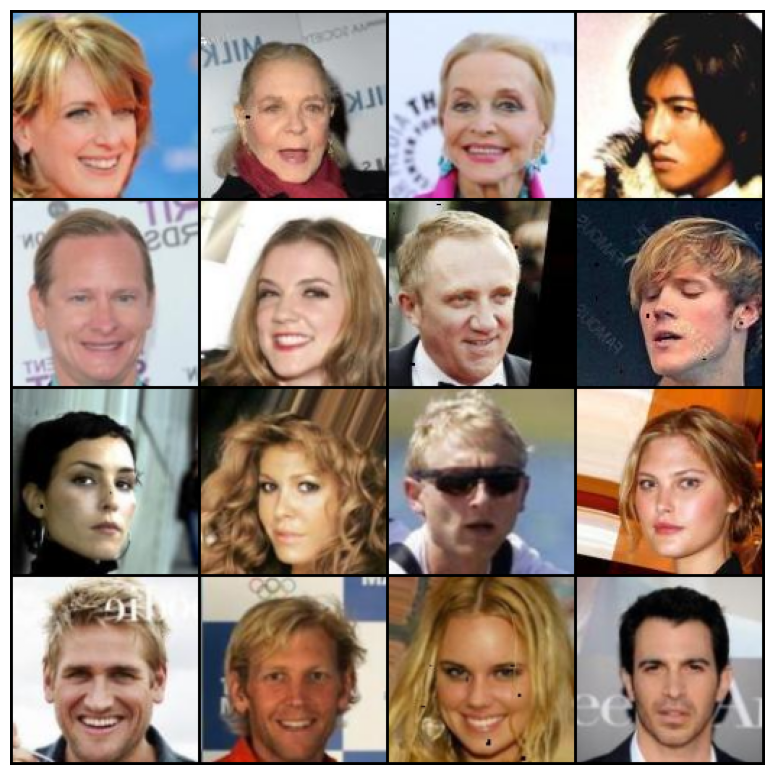

In [28]:

# plot the images
grid = make_grid(
    blond_hair_batch, nrow=4, normalize=True, value_range=(0, 1)
)  # Normalizes images to [0, 1]


# Option 2: Display the grid using matplotlib
def tensor_to_numpy(image_tensor):
    # Convert from tensor to NumPy for plotting
    image = image_tensor.cpu().permute(1, 2, 0)  # (C, H, W) -> (H, W, C)
    return image.numpy()


# Convert the grid to a NumPy array and display
grid_np = tensor_to_numpy(grid)
plt.figure(figsize=(8, 8))
plt.imshow(grid_np)
plt.axis("off")
plt.show()

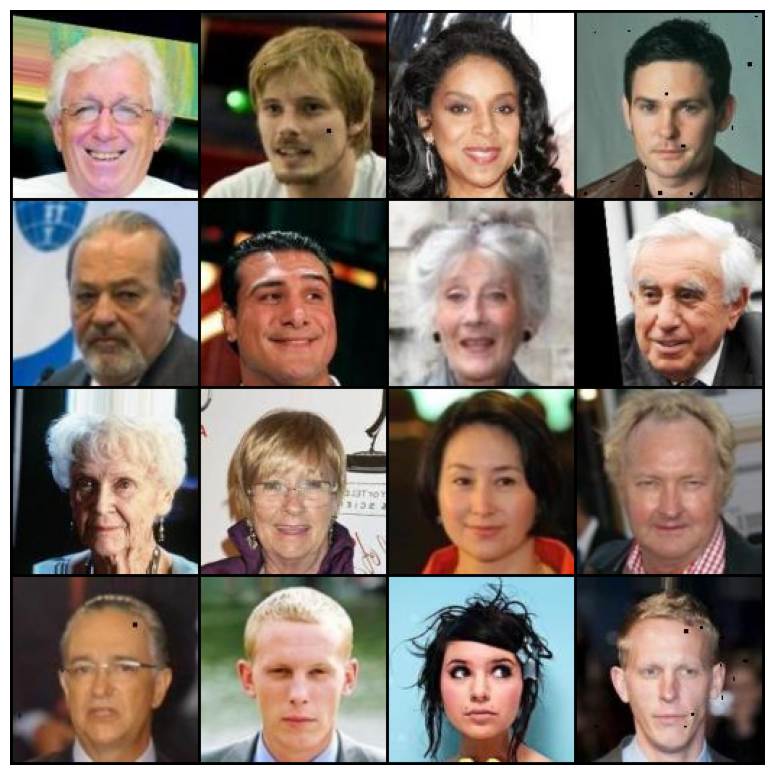

In [29]:

# plot the images
grid = make_grid(
    black_hair_batch, nrow=4, normalize=True, value_range=(0, 1)
)  # Normalizes images to [0, 1]


# Option 2: Display the grid using matplotlib
def tensor_to_numpy(image_tensor):
    # Convert from tensor to NumPy for plotting
    image = image_tensor.cpu().permute(1, 2, 0)  # (C, H, W) -> (H, W, C)
    return image.numpy()


# Convert the grid to a NumPy array and display
grid_np = tensor_to_numpy(grid)
plt.figure(figsize=(8, 8))
plt.imshow(grid_np)
plt.axis("off")
plt.show()

## Pass images through causal model and perform exchange of latent space

In [30]:
def compute_latent_space(batch_imgs, vae_model, nf_model):
    # map this batch to VAE latent space
    batch_imgs = batch_imgs.to(device)
    encoded_rep, _ = vae_model.encoder.encode(batch_imgs)

    # map VAe latent space to a causal space and apply intervention on hair color
    causal_rep = nf_model.inverse(encoded_rep)

    return causal_rep

blond_rep = compute_latent_space(blond_hair_batch, vae_model, nf_model=model)
black_rep = compute_latent_space(black_hair_batch, vae_model, nf_model=model)

print(blond_rep.shape, black_rep.shape)

torch.Size([16, 48]) torch.Size([16, 48])


In [31]:
def exchange_latent_space(img_batch_A, img_batch_B, hc_dim=4):
    img_batch_A[:, 48 - hc_dim : 48], img_batch_B[:, 48 - hc_dim : 48] = (
        img_batch_B[:, 48 - hc_dim : 48],
        img_batch_A[:, 48 - hc_dim : 48],
    )
    return img_batch_A, img_batch_B

blond_rep, black_rep = exchange_latent_space(blond_rep, black_rep)

print(blond_rep.shape, black_rep.shape)

torch.Size([16, 48]) torch.Size([16, 48])


In [32]:
def reconstruct_from_latent(causal_rep, vae_model, nf_model):
    # map back to VAE latent space, and then back to image space
    perturbed_encoding_rep = nf_model.forward(causal_rep)#.to(device)
    reconstructed_imgs = vae_model.decode(perturbed_encoding_rep)
    return reconstructed_imgs


blond_hair_recon = reconstruct_from_latent(blond_rep, vae_model, model)
black_hair_recon = reconstruct_from_latent(black_rep, vae_model, model)

print(blond_hair_recon.shape, black_hair_recon.shape)

torch.Size([16, 3, 128, 128]) torch.Size([16, 3, 128, 128])


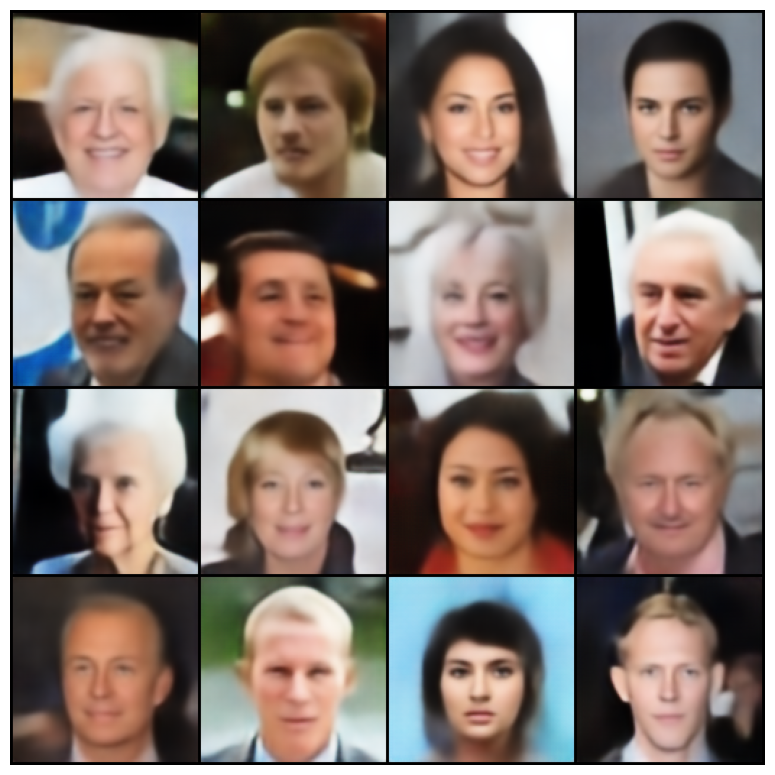

In [33]:

# plot the images
grid = make_grid(
    black_hair_recon, nrow=4, normalize=True, value_range=(0, 1)
)  # Normalizes images to [0, 1]


# Option 2: Display the grid using matplotlib
def tensor_to_numpy(image_tensor):
    # Convert from tensor to NumPy for plotting
    image = image_tensor.cpu().permute(1, 2, 0)  # (C, H, W) -> (H, W, C)
    return image.numpy()


# Convert the grid to a NumPy array and display
grid_np = tensor_to_numpy(grid)
plt.figure(figsize=(8, 8))
plt.imshow(grid_np)
plt.axis("off")
plt.show()

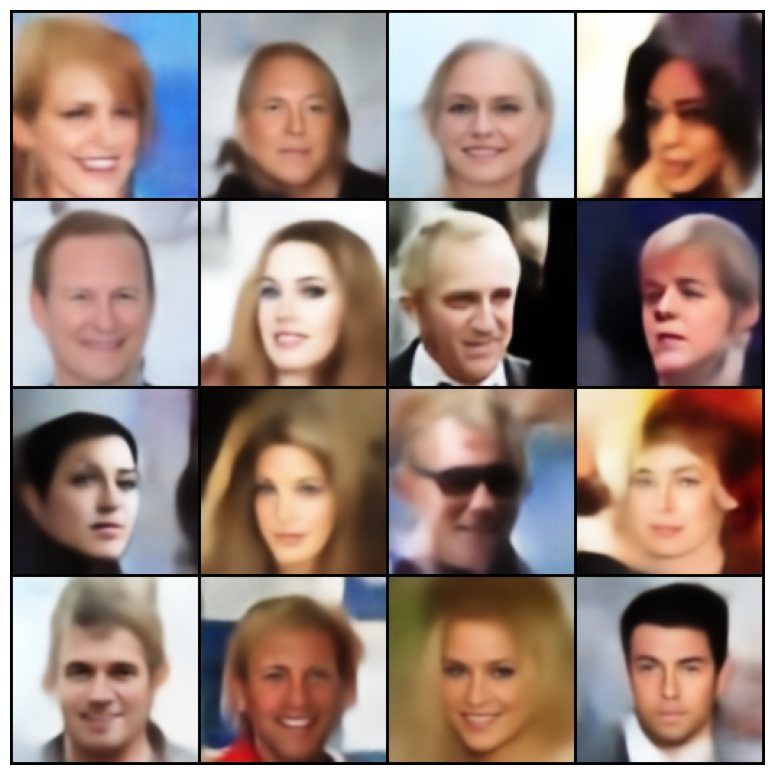

In [34]:

# plot the images
grid = make_grid(
    blond_hair_recon, nrow=4, normalize=True, value_range=(0, 1)
)  # Normalizes images to [0, 1]


# Option 2: Display the grid using matplotlib
def tensor_to_numpy(image_tensor):
    # Convert from tensor to NumPy for plotting
    image = image_tensor.cpu().permute(1, 2, 0)  # (C, H, W) -> (H, W, C)
    return image.numpy()


# Convert the grid to a NumPy array and display
grid_np = tensor_to_numpy(grid)
plt.figure(figsize=(8, 8))
plt.imshow(grid_np)
plt.axis("off")
plt.show()